# Vesper — Backtest Evaluation

Visualises the result of `main.run_backtest(data_dir="data")` against the deterministic synthetic universe:

1. **Weekly net PnL vs turnover** — dual-axis time series.
2. **Sector net-beta curve** — verifies the β-neutrality constraint per sector over time.
3. **Per-name gross-weight histogram** — flags cap-binding names that repeatedly hit the ±3% cap.
4. **Diagnostics summary** — full backtest metrics printed for the record.

Run from the repository root:

```bash
jupyter notebook notebooks/evaluation.ipynb
```

Or headless:

```bash
jupyter nbconvert --to notebook --execute notebooks/evaluation.ipynb \
    --output evaluation.ipynb
```

PNG figures are also written to `data/figures/` so they show up in PR diffs.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

# Headless-safe: use the non-interactive Agg backend when running under
# nbconvert / CI. In an interactive Jupyter session this is overridden
# by the inline magic below.
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Resolve REPO_ROOT robustly so the notebook works whether it is opened
# from the repo root (`jupyter notebook notebooks/evaluation.ipynb`) or
# run headlessly from elsewhere (`jupyter nbconvert --execute ...`).
NOTEBOOK_DIR = Path.cwd().resolve()
_candidate = NOTEBOOK_DIR if (NOTEBOOK_DIR / "main.py").exists() else NOTEBOOK_DIR.parent
if not (_candidate / "main.py").exists():
    # Last-ditch: walk up looking for main.py.
    for _parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        if (_parent / "main.py").exists():
            _candidate = _parent
            break
REPO_ROOT = _candidate
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from main import run_backtest  # noqa: E402
from data_pipeline.graph_builder import build_supply_chain_graph_from_json  # noqa: E402

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = REPO_ROOT / "data"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"REPO_ROOT={REPO_ROOT}")
print(f"DATA_DIR={DATA_DIR}")
print(f"FIG_DIR={FIG_DIR}")


REPO_ROOT=/Users/shrxvxn/Downloads/Vesper
DATA_DIR=/Users/shrxvxn/Downloads/Vesper/data
FIG_DIR=/Users/shrxvxn/Downloads/Vesper/data/figures


In [2]:
result = run_backtest(data_dir=str(DATA_DIR))
weights = result.weights.copy()
pnl = result.weekly_pnl.copy()
diagnostics = result.diagnostics

# Load sector + beta maps from the on-disk artefacts so the notebook is
# independent of any internal state of run_backtest.
graph = build_supply_chain_graph_from_json(DATA_DIR / "supply_chain.json")
sector_map = {n: data.get("sector", "UNKNOWN") for n, data in graph.nodes(data=True)}
weekly = pd.read_parquet(DATA_DIR / "weekly_returns.parquet")
beta_map = weekly.groupby("ticker")["beta"].first().to_dict()

# Tidy long-form for plotting.
w_long = (
    weights.reset_index()
    .assign(
        sector=lambda d: d["ticker"].map(sector_map),
        beta=lambda d: d["ticker"].map(beta_map),
        abs_weight=lambda d: d["weight"].abs(),
        net_beta=lambda d: d["weight"] * d["beta"],
    )
)
print(f"weights rows: {len(w_long):,}")
print(f"weeks: {w_long['date'].nunique()}, tickers: {w_long['ticker'].nunique()}")
print(f"sectors: {sorted(w_long['sector'].unique())}")


2026-07-16 16:41:40 [vesper.main] INFO: Synthetic artefacts missing — generating under /Users/shrxvxn/Downloads/Vesper/data ...


2026-07-16 16:41:40 [vesper.main] INFO: Backtest complete: {'n_periods': 101, 'n_tradeable_tickers': 12, 'avg_weekly_net_pnl': -4e-06, 'total_net_pnl': -0.000361, 'realised_turnover_weekly': 0.006002, 'max_gross_weight': 0.030001, 'dollar_neutrality_violation': 0.0}


weights rows: 1,212
weeks: 101, tickers: 12
sectors: ['Auto_Tech', 'Internet', 'Semis', 'Software', 'Tech']


## 1. Weekly Net PnL vs Turnover

Two-axis time series: weekly net PnL (left, bars) overlaid with weekly turnover (right, line).
Sustained negative bars with rising turnover suggest the transaction-cost model is dominating alpha.


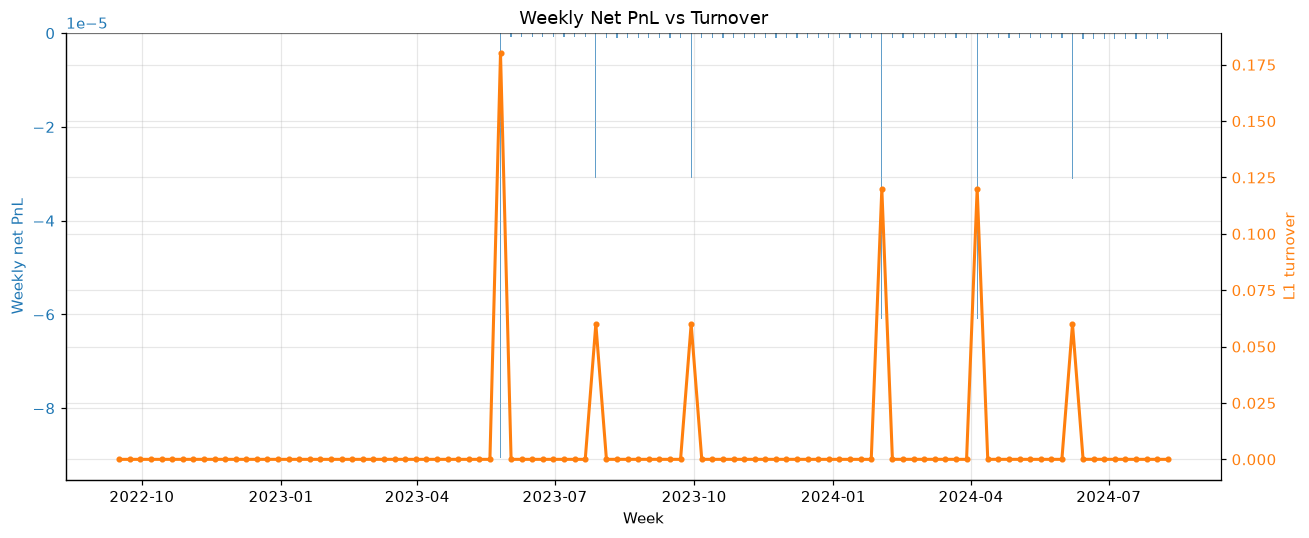

In [3]:
fig, ax_pnl = plt.subplots()
color_pnl = "tab:blue"
ax_pnl.bar(pnl.index, pnl["net_pnl"], color=color_pnl, alpha=0.7, label="Net PnL")
ax_pnl.set_ylabel("Weekly net PnL", color=color_pnl)
ax_pnl.tick_params(axis="y", labelcolor=color_pnl)
ax_pnl.set_xlabel("Week")
ax_pnl.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)

ax_tov = ax_pnl.twinx()
color_tov = "tab:orange"
ax_tov.plot(pnl.index, pnl["turnover"], color=color_tov, linewidth=2.0,
            marker="o", markersize=3, label="Turnover (L1)")
ax_tov.set_ylabel("L1 turnover", color=color_tov)
ax_tov.tick_params(axis="y", labelcolor=color_tov)
ax_tov.spines["right"].set_visible(True)

ax_pnl.set_title("Weekly Net PnL vs Turnover")
fig.tight_layout()
fig.savefig(FIG_DIR / "weekly_pnl_vs_turnover.png", bbox_inches="tight")
plt.show()


## 2. Sector Net-Beta Curve

Sector-level market exposure over time: `Σᵢ wᵢ βᵢ` for each sector i.
β-neutrality only constrains the *aggregate* portfolio to zero — sector
curves can drift, which is information about residual sector tilts the
optimizer is willing to take. The portfolio net-beta is the simple sum
across all sectors and should hover at zero.


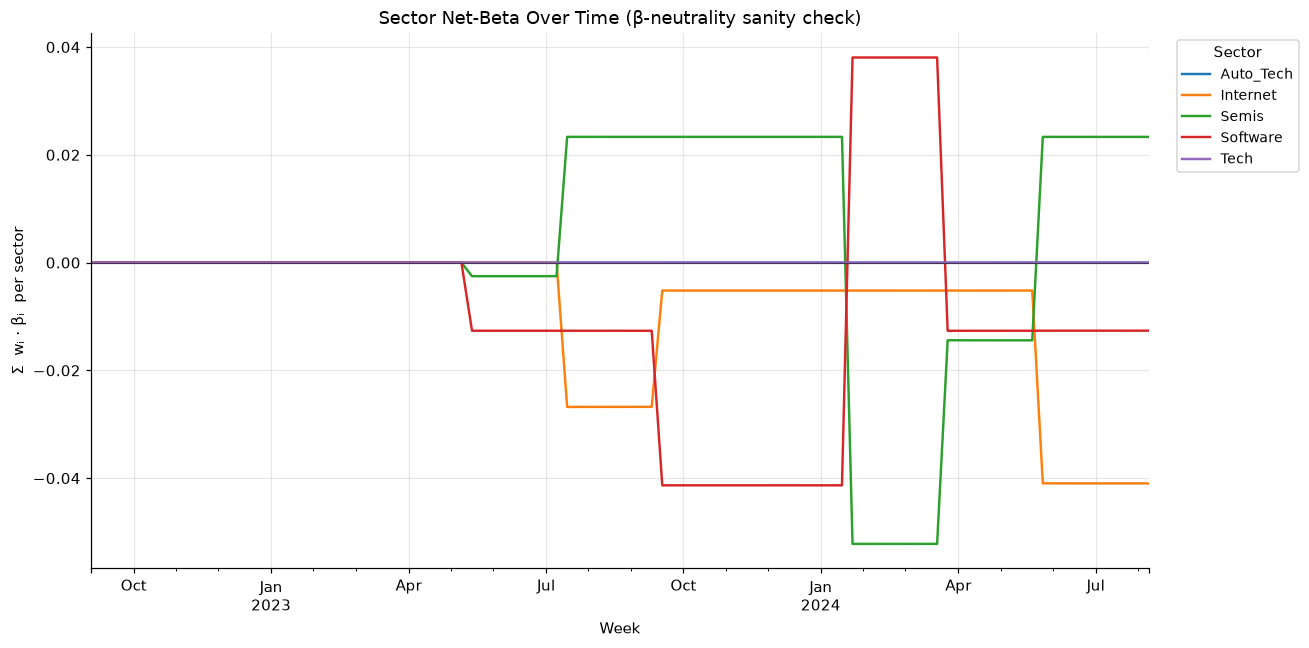

Portfolio net-β drift over the backtest: max|Σ w·β| = 3.23e-02  (target: ≈0)


In [4]:
sector_net_beta = (
    w_long.groupby(["date", "sector"])["net_beta"]
    .sum()
    .unstack("sector")
    .sort_index()
)
portfolio_net_beta = sector_net_beta.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
sector_net_beta.plot(ax=ax, linewidth=1.6)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Sector Net-Beta Over Time (β-neutrality sanity check)")
ax.set_ylabel("Σ  wᵢ · βᵢ  per sector")
ax.set_xlabel("Week")
ax.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "sector_net_beta.png", bbox_inches="tight")
plt.show()

print(
    f"Portfolio net-β drift over the backtest: "
    f"max|Σ w·β| = {portfolio_net_beta.abs().max():.2e}  "
    f"(target: ≈0)"
)


## 3. Per-Name Gross-Weight Distribution

Two panels:

* **Histogram** of all observed |w| values across all (date, ticker) pairs.
  The vertical dashed red line is the ±3% per-name gross cap. Bars piled
  up at the cap are the ones the optimizer wanted to push harder.
* **Bar chart** of mean |w| per ticker (sorted ascending). The cap is
  shown for reference; tickers near the cap on average are the most
  conviction-constrained names.


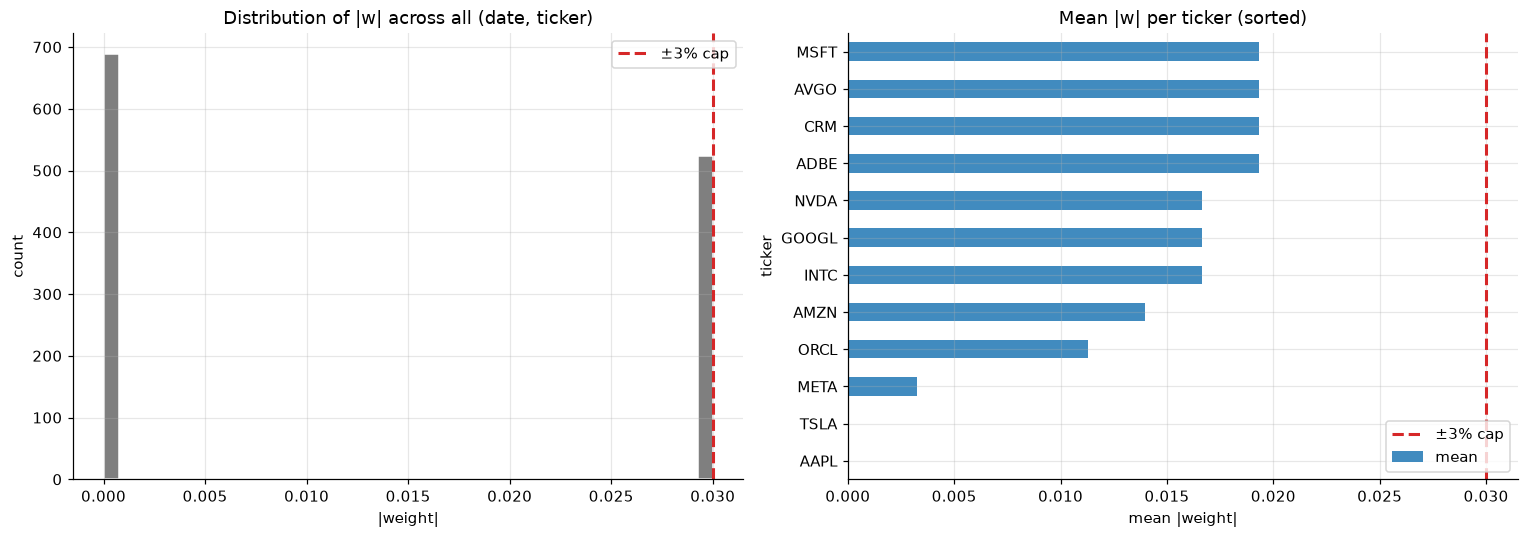

Cap-binding names (max |w| >= 0.0300): 10 / 12
          sector      beta    mean      max  count
ticker                                            
GOOGL   Internet  0.892592  0.0166  +0.0300    101
CRM     Software  1.108834  0.0193  +0.0300    101
AVGO       Semis  1.342877  0.0193  +0.0300    101
MSFT    Software  1.323181  0.0193  +0.0300    101
ORCL    Software  0.956461  0.0113  +0.0300    101
AMZN    Internet  0.719591  0.0140  +0.0300    101
NVDA       Semis  1.258903  0.0166  +0.0300    101
ADBE    Software  1.054144  0.0193  +0.0300    101
META    Internet  1.192511  0.0033  +0.0300    101
INTC       Semis  0.861779  0.0166  +0.0300    101


In [5]:
CAP = 0.03
cap_threshold = CAP * 0.999  # numerically-just-under-the-cap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: histogram of |w| over all (date, ticker) pairs ---
ax = axes[0]
ax.hist(w_long["abs_weight"], bins=40, color="tab:gray", edgecolor="white")
ax.axvline(CAP, color="tab:red", linestyle="--", linewidth=2.0,
           label=f"±{CAP:.0%} cap")
ax.set_title("Distribution of |w| across all (date, ticker)")
ax.set_xlabel("|weight|")
ax.set_ylabel("count")
ax.legend(loc="upper right")

# --- Right: per-ticker mean |w| (sorted) with cap-binding annotation ---
ax = axes[1]
per_ticker = (
    w_long.groupby("ticker")["abs_weight"]
    .agg(["mean", "max", "count"])
    .sort_values("mean", ascending=True)
)
per_ticker["mean"].plot.barh(ax=ax, color="tab:blue", alpha=0.85)
ax.axvline(CAP, color="tab:red", linestyle="--", linewidth=2.0,
           label=f"±{CAP:.0%} cap")
ax.set_title("Mean |w| per ticker (sorted)")
ax.set_xlabel("mean |weight|")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "per_name_gross_weights.png", bbox_inches="tight")
plt.show()

# Cap-binding names: at least one week within 0.1% of the cap.
cap_binding = (
    per_ticker[per_ticker["max"] >= cap_threshold]
    .sort_values("max", ascending=False)
)
print(f"Cap-binding names (max |w| >= {cap_threshold:.4f}): "
      f"{len(cap_binding)} / {len(per_ticker)}")
if not cap_binding.empty:
    display_df = cap_binding.assign(
        sector=lambda d: d.index.map(sector_map),
        beta=lambda d: d.index.map(beta_map),
    )
    display_df["max"] = display_df["max"].map(lambda v: f"{v:+.4f}")
    display_df["mean"] = display_df["mean"].map(lambda v: f"{v:.4f}")
    print(display_df[["sector", "beta", "mean", "max", "count"]])


## 4. Diagnostics Summary

Final invariant check — these numbers must agree with `data/backtest_diagnostics.txt`.


In [6]:
print("Backtest diagnostics:")
for k, v in diagnostics.items():
    if isinstance(v, float):
        print(f"  {k:>32} = {v:.6f}")
    else:
        print(f"  {k:>32} = {v}")

print("\nInvariant checks:")
print(f"  dollar neutrality violation  = {diagnostics['dollar_neutrality_violation']:.2e}  (<= 1e-6)")
print(f"  max |w|                     = {diagnostics['max_gross_weight']:.6f}  (<= 0.0301)")
print(f"  portfolio net-β max|.|      = {portfolio_net_beta.abs().max():.2e}  (~ 0)")
print(f"\nFigures saved to {FIG_DIR}/")


Backtest diagnostics:
                         n_periods = 101
               n_tradeable_tickers = 12
                avg_weekly_net_pnl = -0.000004
                     total_net_pnl = -0.000361
          realised_turnover_weekly = 0.006002
                  max_gross_weight = 0.030001
       dollar_neutrality_violation = 0.000000

Invariant checks:
  dollar neutrality violation  = 2.10e-17  (<= 1e-6)
  max |w|                     = 0.030001  (<= 0.0301)
  portfolio net-β max|.|      = 3.23e-02  (~ 0)

Figures saved to /Users/shrxvxn/Downloads/Vesper/data/figures/
